In [1]:
import numpy as np
import pandas as pd

In [2]:
t001_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.01/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")
t001_fold0["fold"] = [0 for i in range(len(t001_fold0))]
t001_fold0["tau"] = [0.01 for i in range(len(t001_fold0))]

In [3]:
t001_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.01/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")
t001_fold1["fold"] = [1 for i in range(len(t001_fold1))]
t001_fold1["tau"] = [0.01 for i in range(len(t001_fold1))]

In [4]:
t001_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.01/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")
t001_fold2["fold"] = [2 for i in range(len(t001_fold2))]
t001_fold2["tau"] = [0.01 for i in range(len(t001_fold2))]

In [5]:
t01_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.1/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")
t01_fold0["fold"] = [0 for i in range(len(t01_fold0))]
t01_fold0["tau"] = [0.1 for i in range(len(t01_fold0))]

In [6]:
t01_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.1/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")
t01_fold1["fold"] = [1 for i in range(len(t01_fold1))]
t01_fold1["tau"] = [0.1 for i in range(len(t01_fold1))]

In [7]:
t01_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_0.1/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")
t01_fold2["fold"] = [2 for i in range(len(t01_fold2))]
t01_fold2["tau"] = [0.1 for i in range(len(t01_fold2))]

In [8]:
t1_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_1.0/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")
t1_fold0["fold"] = [0 for i in range(len(t1_fold0))]
t1_fold0["tau"] = [1.0 for i in range(len(t1_fold0))]

In [9]:
t1_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_1.0/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")
t1_fold1["fold"] = [1 for i in range(len(t1_fold1))]
t1_fold1["tau"] = [1.0 for i in range(len(t1_fold1))]

In [10]:
t1_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_1.0/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")
t1_fold2["fold"] = [2 for i in range(len(t1_fold2))]
t1_fold2["tau"] = [1.0 for i in range(len(t1_fold2))]

In [11]:
t10_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_10.0/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")
t10_fold0["fold"] = [0 for i in range(len(t10_fold0))]
t10_fold0["tau"] = [10.0 for i in range(len(t10_fold0))]

In [12]:
t10_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_10.0/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")
t10_fold1["fold"] = [1 for i in range(len(t10_fold1))]
t10_fold1["tau"] = [10.0 for i in range(len(t10_fold1))]

In [13]:
t10_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_tau/tau_10.0/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")
t10_fold2["fold"] = [2 for i in range(len(t10_fold2))]
t10_fold2["tau"] = [10.0 for i in range(len(t10_fold2))]

In [14]:
df = pd.concat([t001_fold0, t001_fold1, t001_fold2,
                t01_fold0, t01_fold1, t01_fold2,
                t1_fold0, t1_fold1, t1_fold2,
                t10_fold0, t10_fold1, t10_fold2], ignore_index=True)

In [15]:
# optimizations with no edits
counts = df.groupby("tau")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

tau
0.01     0
0.10     0
1.00     0
10.00    0
Name: num_edits, dtype: int64


In [16]:
# eliminating them
df = df[df["num_edits"] > 0]

In [17]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [18]:
# optimizations with edits but not sufficent URQ score
urq_counts = df.groupby("tau")["URQ_diff"].apply(lambda x: (x >= 0.0).sum())
print(urq_counts)

tau
0.01     2
0.10     0
1.00     0
10.00    0
Name: URQ_diff, dtype: int64


In [19]:
# eliminating them
df = df[df["URQ_diff"] < 0.0]

In [20]:
len(df)

654

In [21]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("tau")["num_edits"].mean()
print(avg_num_edits)

tau
0.01       44.771605
0.10      326.792683
1.00      793.201220
10.00    1061.713415
Name: num_edits, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

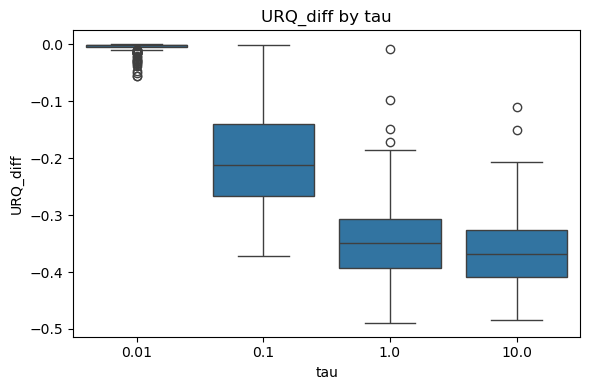

In [23]:
order = sorted(df["tau"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="tau", y="URQ_diff", order=order)
plt.xlabel("tau")
plt.ylabel("URQ_diff")
plt.title("URQ_diff by tau")
plt.tight_layout()
plt.show()

In [24]:
# successful optimizations only, average URQ diff
avg_urq_diff = df.groupby("tau")["URQ_diff"].mean()
print(avg_urq_diff)

tau
0.01    -0.006097
0.10    -0.195159
1.00    -0.344230
10.00   -0.364975
Name: URQ_diff, dtype: float64


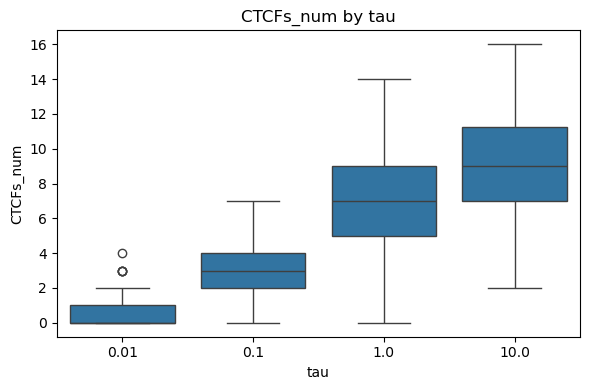

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="tau", y="CTCFs_num", order=order)
plt.xlabel("tau")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by tau")
plt.tight_layout()
plt.show()

In [26]:
# successful optimizations only, average number of CTCFs
avg_ctcf_num = df.groupby("tau")["CTCFs_num"].mean()
print(avg_ctcf_num)

tau
0.01     0.592593
0.10     2.737805
1.00     7.085366
10.00    9.146341
Name: CTCFs_num, dtype: float64


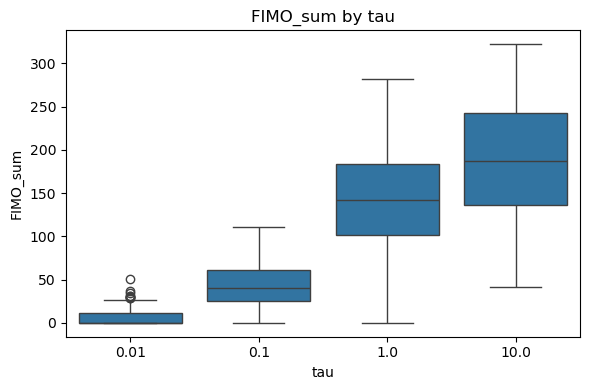

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="tau", y="FIMO_sum", order=order)
plt.xlabel("tau")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by tau")
plt.tight_layout()
plt.show()

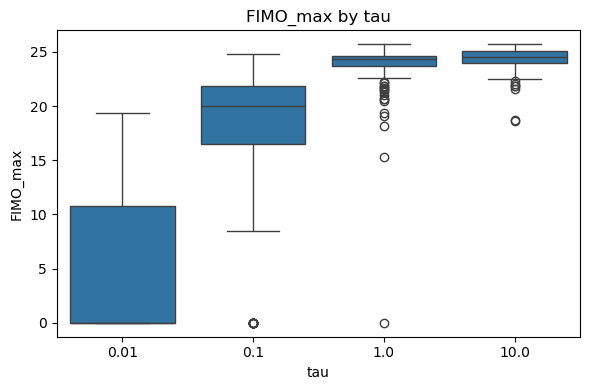

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="tau", y="FIMO_max", order=order)
plt.xlabel("tau")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by tau")
plt.tight_layout()
plt.show()